In [1]:
'''
# 🤖 Machine Learning

## 🎯 Objective

The objective of this notebook is to build machine learning models to predict the order value of an e-commerce purchase using customer, product, payment, and delivery-related features.

The notebook follows a complete machine learning workflow including data preprocessing, feature engineering, model training, evaluation, comparison, and model saving.
'''

'\n# 🤖 Machine Learning\n\n## 🎯 Objective\n\nThe objective of this notebook is to build machine learning models to predict the order value of an e-commerce purchase using customer, product, payment, and delivery-related features.\n\nThe notebook follows a complete machine learning workflow including data preprocessing, feature engineering, model training, evaluation, comparison, and model saving.\n'

In [2]:
'''
## 📖 Description

Machine learning enables businesses to make predictions using historical data. In this notebook, we will use the engineered e-commerce dataset to train multiple regression models and compare their performance.

The workflow includes:

- Data Preparation
- Feature Selection
- Handling Missing Values
- Encoding Categorical Variables
- Train-Test Split
- Model Training
- Model Evaluation
- Model Comparison
- Model Saving
'''

'\n## 📖 Description\n\nMachine learning enables businesses to make predictions using historical data. In this notebook, we will use the engineered e-commerce dataset to train multiple regression models and compare their performance.\n\nThe workflow includes:\n\n- Data Preparation\n- Feature Selection\n- Handling Missing Values\n- Encoding Categorical Variables\n- Train-Test Split\n- Model Training\n- Model Evaluation\n- Model Comparison\n- Model Saving\n'

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../data/processed/engineered_data.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,purchase_year,purchase_month,purchase_day,purchase_day_name,purchase_hour,purchase_quarter,is_weekend,delivery_days,approval_days,estimated_delivery_gap,late_delivery,total_order_value,high_value_order,revenue_bucket,order_value,customer_order_count,repeat_customer,customer_total_spending,average_order_value_per_customer,installment_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,2017,10,2,Monday,10,4,False,8.0,0.0,7.0,False,38.71,False,Medium,116.13,2,True,392.50,196.25,Single Payment
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,2017,10,2,Monday,10,4,False,8.0,0.0,7.0,False,38.71,False,Medium,116.13,2,True,392.50,196.25,Single Payment
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,2017,10,2,Monday,10,4,False,8.0,0.0,7.0,False,38.71,False,Medium,116.13,2,True,392.50,196.25,Single Payment
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,2018,7,24,Tuesday,20,3,False,13.0,1.0,5.0,False,141.46,False,Medium,141.46,1,False,141.46,141.46,Single Payment
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Comment,2018-08-18,2018-08-22 1

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (119143, 56)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 56 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   order_id                          119143 non-null  object 
 1   customer_id                       119143 non-null  object 
 2   order_status                      119143 non-null  object 
 3   order_purchase_timestamp          119143 non-null  object 
 4   order_approved_at                 118966 non-null  object 
 5   order_delivered_carrier_date      117057 non-null  object 
 6   order_delivered_customer_date     115722 non-null  object 
 7   order_estimated_delivery_date     119143 non-null  object 
 8   customer_unique_id                119143 non-null  object 
 9   customer_zip_code_prefix          119143 non-null  int64  
 10  customer_city                     119143 non-null  object 
 11  customer_state                    119143 non-null  o

In [7]:
df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,review_score,purchase_year,purchase_month,purchase_day,purchase_hour,purchase_quarter,delivery_days,approval_days,estimated_delivery_gap,total_order_value,order_value,customer_order_count,customer_total_spending,average_order_value_per_customer
count,119143.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,118310.000000,119140.000000,119140.000000,119140.000000,118146.000000,119143.000000,119143.000000,119143.000000,119143.000000,119143.000000,115722.000000,118966.000000,115722.000000,118310.000000,119143.000000,119143.000000,119143.000000,119143.000000
mean,35033.451298,1.196543,120.646603,20.032387,48.799746,783.209272,2.187753,2112.012002,30.264255,16.619094,23.074279,1.094737,2.941246,172.735135,4.015582,2017.535290,6.033086,15.551321,14.755537,2.356362,12.022589,0.274465,11.048392,140.678990,216.025218,1.091126,1031.473286,887.433452
std,29823.198969,0.699489,184.109691,15.836850,9.964369,648.254189,1.711055,3786.419544,16.188144,13.452529,11.748214,0.730141,2.777848,267.776077,1.400436,0.505591,3.233819,8.664547,5.327825,1.063027,9.454922,0.980584,10.163801,191.239906,469.002575,0.410960,10315.336158,8839.276965
min,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000,0.000000,0.000000,1.000000,2016.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,-189.000000,6.080000,0.000000,1.000000,0.000000,0.000000
25%,11250.000000,1.000000,39.900000,13.080000,43.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,1.000000,1.000000,60.850000,4.000000,2017.000000,3.000000,8.000000,11.000000,1.000000,6.000000,0.000000,6.000000,55.240000,67.600000,1.000000,73.340000,71.780000
50%,24240.000000,1.000000,74.900000,16.280000,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000,1.000000,2.000000,108.160000,5.000000,2018.000000,6.000000,16.000000,15.000000,2.000000,10.000000,0.000000,12.000000,91.990000,120.030000,1.000000,146.340000,139.180000
75%,58475.000000,1.000000,134.900000,21.180000,57.000000,977.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,1.000000,4.000000,189.240000,5.000000,2018.000000,8.000000,23.000000,19.000000,3.000000,15.000000,0.000000,16.000000,157.615000,212.585000,1.000000,340.600000,311.595000
max,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,29.000000,24.000000,13664.080000,5.000000,2018.000000,12.000000,31.000000,23.000000,4.000000,209.000000,187.000000,146.000000,6929.310000,13664.080000,17.000000,385169.590000,385169.590000


In [8]:
df.isnull().sum()

order_id                               0
customer_id                            0
order_status                           0
order_purchase_timestamp               0
order_approved_at                    177
order_delivered_carrier_date        2086
order_delivered_customer_date       3421
order_estimated_delivery_date          0
customer_unique_id                     0
customer_zip_code_prefix               0
customer_city                          0
customer_state                         0
order_item_id                        833
product_id                           833
seller_id                            833
shipping_limit_date                  833
price                                833
freight_value                        833
product_category_name                833
product_name_lenght                  833
product_description_lenght           833
product_photos_qty                   833
product_weight_g                     833
product_length_cm                    833
product_height_c

In [9]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,purchase_year,purchase_month,purchase_day,purchase_day_name,purchase_hour,purchase_quarter,is_weekend,delivery_days,approval_days,estimated_delivery_gap,late_delivery,total_order_value,high_value_order,revenue_bucket,order_value,customer_order_count,repeat_customer,customer_total_spending,average_order_value_per_customer,installment_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,2017,10,2,Monday,10,4,False,8.0,0.0,7.0,False,38.71,False,Medium,116.13,2,True,392.50,196.25,Single Payment
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,2017,10,2,Monday,10,4,False,8.0,0.0,7.0,False,38.71,False,Medium,116.13,2,True,392.50,196.25,Single Payment
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,2017,10,2,Monday,10,4,False,8.0,0.0,7.0,False,38.71,False,Medium,116.13,2,True,392.50,196.25,Single Payment
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,2018,7,24,Tuesday,20,3,False,13.0,1.0,5.0,False,141.46,False,Medium,141.46,1,False,141.46,141.46,Single Payment
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Comment,2018-08-18,2018-08-22 1

In [10]:
'''
# Feature Selection

Select the target variable and predictor variables.

Target Variable:
- order_value

Remove columns that:
- uniquely identify records
- contain timestamps
- directly leak the target value
'''

'\n# Feature Selection\n\nSelect the target variable and predictor variables.\n\nTarget Variable:\n- order_value\n\nRemove columns that:\n- uniquely identify records\n- contain timestamps\n- directly leak the target value\n'

In [11]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'purchase_year',
 'purchase_month',
 'purchase_day',
 'purchase_day_name',
 'purchase_hour',
 'purchase_quarter',
 'is_weekend',
 'delivery_days',
 'approval_days',
 'estimated_delivery_gap',
 'late_deliv

In [14]:
'''
# Feature Selection

The target variable for this regression problem is **order_value**.

Identifier columns, timestamp columns, text columns, and target leakage columns are removed to build a realistic machine learning model.
'''

'\n# Feature Selection\n\nThe target variable for this regression problem is **order_value**.\n\nIdentifier columns, timestamp columns, text columns, and target leakage columns are removed to build a realistic machine learning model.\n'

In [15]:
# Target Variable
y = df["order_value"]

# Columns to Remove
drop_columns = [

    # IDs
    'order_id',
    'customer_id',
    'customer_unique_id',
    'product_id',
    'seller_id',
    'review_id',

    # Date Columns
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp',

    # Text Columns
    'review_comment_title',
    'review_comment_message',

    # Target Leakage
    'price',
    'freight_value',
    'total_order_value',
    'payment_value',
    'high_value_order',
    'revenue_bucket',
    'customer_total_spending',
    'average_order_value_per_customer',
    'order_value'
]

X = df.drop(columns=drop_columns)

In [16]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (119143, 31)
Target Shape: (119143,)


In [17]:
X.head()

,order_status,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,review_score,purchase_year,purchase_month,purchase_day,purchase_day_name,purchase_hour,purchase_quarter,is_weekend,delivery_days,approval_days,estimated_delivery_gap,late_delivery,customer_order_count,repeat_customer,installment_category
0,delivered,3149,sao paulo,SP,1.0,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,4.0,2017,10,2,Monday,10,4,False,8.0,0.0,7.0,False,2,True,Single Payment
1,delivered,3149,sao paulo,SP,1.0,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,4.0,2017,10,2,Monday,10,4,False,8.0,0.0,7.0,False,2,True,Single Payment
2,delivered,3149,sao paulo,SP,1.0,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,4.0,2017,10,2,Monday,10,4,False,8.0,0.0,7.0,False,2,True,Single Payment
3,delivered,47813,barreiras,BA,1.0,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,4.0,2018,7,24,Tuesday,20,3,False,13.0,1.0,5.0,False,1,False,Single Payment
4,delivered,75265,vianopolis,GO,1.0,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,5.0,2018,8,8,Wednesday,8,3,False,9.0,0.0,17.0,False,1,False,Short Installment


In [18]:
'''
# Handle Missing Values

Before training machine learning models, missing values must be handled appropriately. Numerical features will be filled with the median, while categorical features will be filled with the mode.
'''

'\n# Handle Missing Values\n\nBefore training machine learning models, missing values must be handled appropriately. Numerical features will be filled with the median, while categorical features will be filled with the mode.\n'

In [19]:
# Separate Numerical and Categorical Columns

numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = X.select_dtypes(include=['object', 'bool']).columns

print("Numerical Columns:", len(numerical_columns))
print("Categorical Columns:", len(categorical_columns))

Numerical Columns: 21
Categorical Columns: 10


In [20]:
# Fill Numerical Missing Values

for col in numerical_columns:
    X[col] = X[col].fillna(X[col].median())

In [21]:
# Fill Categorical Missing Values

for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

In [23]:
# Check for missing values

print("Total Missing Values:", X.isnull().sum().sum())

X.isnull().sum()

Total Missing Values: 0


order_status                  0
customer_zip_code_prefix      0
customer_city                 0
customer_state                0
order_item_id                 0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
payment_sequential            0
payment_type                  0
payment_installments          0
review_score                  0
purchase_year                 0
purchase_month                0
purchase_day                  0
purchase_day_name             0
purchase_hour                 0
purchase_quarter              0
is_weekend                    0
delivery_days                 0
approval_days                 0
estimated_delivery_gap        0
late_delivery                 0
customer_order_count          0
repeat_customer               0
installment_category          0
dtype: i

In [24]:
'''
# Encode Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical features are converted into numerical values using Label Encoding.

Each unique category is assigned a unique integer value.
'''

'\n# Encode Categorical Variables\n\nMachine learning algorithms require numerical input. Therefore, categorical features are converted into numerical values using Label Encoding.\n\nEach unique category is assigned a unique integer value.\n'

In [25]:
categorical_columns = X.select_dtypes(include=['object', 'bool']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['order_status', 'customer_city', 'customer_state',
       'product_category_name', 'payment_type', 'purchase_day_name',
       'is_weekend', 'late_delivery', 'repeat_customer',
       'installment_category'],
      dtype='object')


In [26]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column].astype(str))

In [27]:
X.head()

,order_status,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,review_score,purchase_year,purchase_month,purchase_day,purchase_day_name,purchase_hour,purchase_quarter,is_weekend,delivery_days,approval_days,estimated_delivery_gap,late_delivery,customer_order_count,repeat_customer,installment_category
0,3,3149,3597,25,1.0,73,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,1,1.0,4.0,2017,10,2,1,10,4,0,8.0,0.0,7.0,0,2,1,3
1,3,3149,3597,25,1.0,73,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,4,1.0,4.0,2017,10,2,1,10,4,0,8.0,0.0,7.0,0,2,1,3
2,3,3149,3597,25,1.0,73,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,4,1.0,4.0,2017,10,2,1,10,4,0,8.0,0.0,7.0,0,2,1,3
3,3,47813,418,4,1.0,63,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,0,1.0,4.0,2018,7,24,5,20,3,0,13.0,1.0,5.0,0,1,0,3
4,3,75265,4050,8,1.0,9,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,1,3.0,5.0,2018,8,8,6,8,3,0,9.0,0.0,17.0,0,1,0,2


In [28]:
'''
# Train-Test Split

The dataset is divided into training and testing sets.

- Training Set: Used to train the machine learning models.
- Testing Set: Used to evaluate the performance of the trained models.

The dataset is split using an 80:20 ratio.
'''

'\n# Train-Test Split\n\nThe dataset is divided into training and testing sets.\n\n- Training Set: Used to train the machine learning models.\n- Testing Set: Used to evaluate the performance of the trained models.\n\nThe dataset is split using an 80:20 ratio.\n'

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features : (95314, 31)
Testing Features  : (23829, 31)
Training Target : (95314,)
Testing Target  : (23829,)


In [30]:
'''
# Model Training

In this section, multiple regression models are trained using the training dataset. Their performance will later be compared to identify the best-performing model.

Models:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
'''

'\n# Model Training\n\nIn this section, multiple regression models are trained using the training dataset. Their performance will later be compared to identify the best-performing model.\n\nModels:\n- Linear Regression\n- Decision Tree Regressor\n- Random Forest Regressor\n'

## Linear Regression

Linear Regression is a simple and interpretable regression algorithm that models the relationship between the input features and the target variable.

In [32]:
# Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [33]:
# Predictions

linear_predictions = linear_model.predict(X_test)

linear_predictions[:10]

array([130.57415734, 134.12642524, 144.89046019, 143.24300062,
       415.45962177, 246.56939998, 176.84523824, 113.90278924,
        23.89202677, 333.90877152])

## Decision Tree Regressor

Decision Trees split the dataset into smaller subsets based on feature values, allowing the model to capture non-linear relationships.

In [35]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [36]:
decision_tree_predictions = decision_tree.predict(X_test)

decision_tree_predictions[:10]

array([158.27, 479.85, 106.3 , 119.2 , 126.73, 161.01, 185.84,  54.6 ,
        66.78, 263.84])

## Random Forest Regressor

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [38]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [39]:
random_forest_predictions = random_forest.predict(X_test)

random_forest_predictions[:10]

array([196.3577, 111.5886, 100.7758,  97.31  , 269.1911, 116.2607,
       101.0733,  80.1884,  75.346 , 222.922 ])

# Model Evaluation

The trained models are evaluated using three standard regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help compare the predictive performance of each model.

In [41]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np


def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")

    return [model_name, mae, rmse, r2]

In [42]:
linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)


Linear Regression
----------------------------------------
MAE : 138.44
RMSE: 365.24
R²  : 0.3500


In [43]:
decision_tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    decision_tree_predictions
)


Decision Tree
----------------------------------------
MAE : 102.92
RMSE: 310.47
R²  : 0.5303


In [44]:
random_forest_results = evaluate_model(
    "Random Forest",
    y_test,
    random_forest_predictions
)


Random Forest
----------------------------------------
MAE : 86.53
RMSE: 222.33
R²  : 0.7591


In [45]:
comparison = pd.DataFrame(
    [
        linear_results,
        decision_tree_results,
        random_forest_results
    ],
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,86.532104,222.333118,0.759129
1,Decision Tree,102.923038,310.474343,0.530293
0,Linear Regression,138.441713,365.242430,0.349963


# Feature Importance

Feature importance measures the contribution of each input feature to the prediction made by the Random Forest model.

Higher importance values indicate that a feature has a greater influence on predicting the target variable.

In [47]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
7,product_description_lenght,0.211227
13,payment_sequential,0.181954
9,product_weight_g,0.110888
25,approval_days,0.077834
1,customer_zip_code_prefix,0.041163
5,product_category_name,0.040584
10,product_length_cm,0.037329
12,product_width_cm,0.028987
4,order_item_id,0.026400
19,purchase_day,0.023412


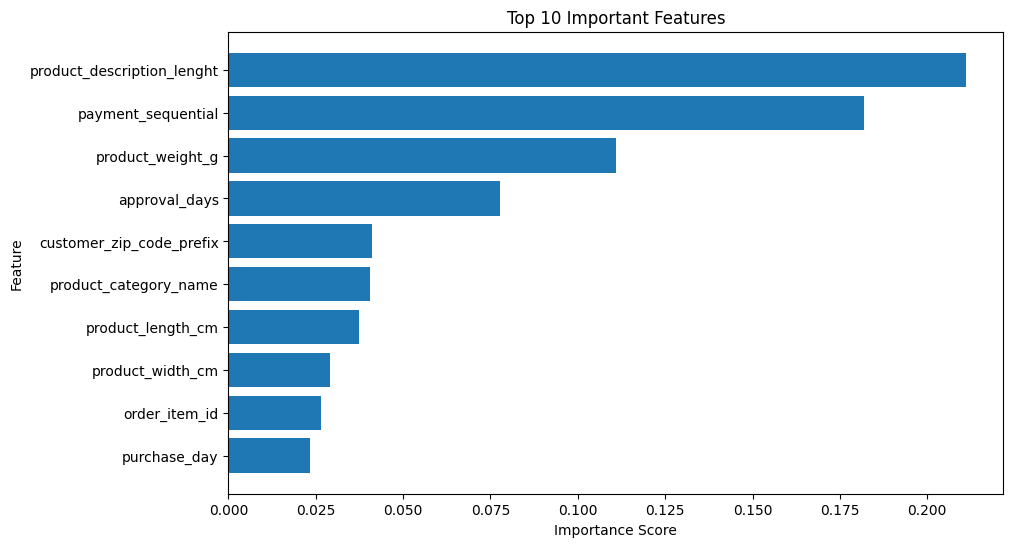

In [48]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

# Model Predictions

Generate predictions on the testing dataset and compare them with the actual values.

In [50]:
predictions = pd.DataFrame({

    "Actual Order Value": y_test,

    "Predicted Order Value": random_forest_predictions

})

predictions.head(20)

,Actual Order Value,Predicted Order Value
56431,63.49,196.3577
48018,305.90,111.5886
12758,80.19,100.7758
114057,208.20,97.3100
68021,352.16,269.1911
62675,106.87,116.2607
104409,87.85,101.0733
90345,59.60,80.1884
10829,64.09,75.3460
46723,263.84,222.9220


# Save Best Model

The Random Forest model achieved the highest R² Score and the lowest prediction errors. Therefore, it is saved for future use.

In [53]:
import os

print(os.getcwd())

C:\Users\HP\Ecommerce_Analytics_Project\notebooks


In [54]:
import os

os.makedirs("../models", exist_ok=True)

In [55]:
import joblib

joblib.dump(
    random_forest,
    "../models/random_forest_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


## Model Comparison Summary

Three regression models were trained and evaluated using MAE, RMSE, and R² Score.

Among all models, Random Forest Regressor achieved the best performance with:

- Lowest Mean Absolute Error (MAE)
- Lowest Root Mean Squared Error (RMSE)
- Highest R² Score

Therefore, Random Forest was selected as the final model for predicting order values.